# V60: Static Markowitz Comparison - No AI, Pure Graph Effect

## Tujuan Eksperimen

Notebook ini membandingkan **3 strategi Markowitz STATIS** (semua **TANPA AI timing**):

### Strategi yang Dibandingkan:

1. **Markowitz Static (All Assets)**
   - Selection: **Semua aset** tanpa filtering
   - Sorting: TIDAK ADA
   - AI Timing: ❌ TIDAK (always invested)
   - Karakteristik: Pure Markowitz, baseline

2. **Markowitz Static + Graph Diversify**
   - Selection: **Graph MIS** dengan korelasi ≤ 0.4
   - Sorting: Markowitz optimal weight
   - AI Timing: ❌ TIDAK (always invested)
   - Karakteristik: Diversifikasi tanpa AI

3. **Markowitz Static + Graph Cluster**
   - Selection: **Graph MIS** dengan korelasi ≥ 0.4
   - Sorting: Markowitz optimal weight
   - AI Timing: ❌ TIDAK (always invested)
   - Karakteristik: Clustering tanpa AI

### Fokus Eksperimen:
Mengukur **Pure Graph Effect** tanpa AI timing:
- Apakah graph diversification meningkatkan Sharpe ratio?
- Apakah graph clustering meningkatkan return?
- Apakah graph filtering worth it tanpa AI?

### Hipotesis:
- **H1:** Diversify meningkatkan Sharpe ratio vs Static
- **H2:** Cluster meningkatkan return vs Static (bullish market)
- **H3:** Graph filtering reduces portfolio size → higher concentration risk

### Parameter:
- AI Timing: **NONE** (all strategies always invested)
- Sorting: Markowitz weight (for graph strategies)
- Transaction Fee: 0.25%
- Rebalancing: 20 hari
- Correlation Threshold: 0.4
- Random Seed: 42

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import random
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Libraries loaded!")

Libraries loaded!


In [2]:
# Load Data
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_index = (1 + market_return).cumprod() * 100

# Test period: 2025
test_dates = returns.loc[returns.index.year == 2025].index

print(f"Data: {len(data)} rows, {len(data.columns)} assets")
print(f"Period: {data.index[0]} to {data.index[-1]}")
print(f"Test period: {test_dates[0]} to {test_dates[-1]}")

Data: 712 rows, 30 assets
Period: 2023-01-02 00:00:00 to 2025-12-30 00:00:00
Test period: 2025-01-02 00:00:00 to 2025-12-30 00:00:00


In [3]:
# Markowitz Optimization Function

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    num_assets = len(mu)

    def objective(w):
        ret = np.sum(w * mu)
        risk = np.sqrt(np.dot(w.T, np.dot(sigma, w)))
        if risk < 0.0001: return 0
        return -(ret / risk)

    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    init_guess = [1./num_assets] * num_assets

    res = minimize(objective, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

print("Markowitz optimization function defined!")

Markowitz optimization function defined!


In [4]:
# Asset Selection Methods

def get_all_assets(returns_window, corr_threshold=None):
    """Strategy 1: Static Markowitz - All Assets, No Filtering"""
    return list(returns_window.columns)

def get_assets_static_diversify(returns_window, corr_threshold=0.4):
    """Strategy 2: Static + Graph Diversify (Markowitz Weight Sort + Low Correlation)"""
    corr_mat = returns_window.corr()
    G = nx.Graph()
    
    # Sort by Markowitz optimal weight
    full_weights = optimize_markowitz(returns_window)
    if not full_weights:
        # Fallback to all assets if optimization fails
        assets = list(returns_window.columns)
    else:
        # Sort by weight (descending)
        assets = sorted(full_weights.items(), key=lambda x: x[1], reverse=True)
        assets = [a[0] for a in assets]
    
    G.add_nodes_from(assets)
    # Edge: Connect if correlation > threshold
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) > corr_threshold:
                G.add_edge(assets[i], assets[j])
    
    # MIS: Select assets NOT connected = low correlation (≤ 0.4)
    selected = list(nx.approximation.maximum_independent_set(G))
    print(f"  Diversify selected: {len(selected)} assets")
    return selected

def get_assets_static_cluster(returns_window, corr_threshold=0.4):
    """Strategy 3: Static + Graph Cluster (Markowitz Weight Sort + High Correlation)"""
    corr_mat = returns_window.corr()
    G = nx.Graph()
    
    # Sort by Markowitz optimal weight
    full_weights = optimize_markowitz(returns_window)
    if not full_weights:
        # Fallback to all assets if optimization fails
        assets = list(returns_window.columns)
    else:
        # Sort by weight (descending)
        assets = sorted(full_weights.items(), key=lambda x: x[1], reverse=True)
        assets = [a[0] for a in assets]
    
    G.add_nodes_from(assets)
    # Edge: Connect if correlation < threshold
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.loc[assets[i], assets[j]]) < corr_threshold:
                G.add_edge(assets[i], assets[j])
    
    # MIS: Select assets NOT connected = high correlation (≥ 0.4)
    selected = list(nx.approximation.maximum_independent_set(G))
    print(f"  Cluster selected: {len(selected)} assets")
    return selected

print("Asset selection methods defined!")

Asset selection methods defined!


In [5]:
# Static Simulation Function (NO AI TIMING)

def run_simulation_static(test_dates, returns, selection_func, fee=0.0025, 
                         g_lookback=60, rebal_period=20, turnover_buffer=0.05):
    """Static Buy & Hold: NO AI, always invested, rebalancing periodik"""
    
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    
    current_weights = {}
    days_since_rebal = 999
    
    # Initial portfolio optimization
    loc_idx = returns.index.get_loc(test_dates[0])
    window_rets = returns.iloc[loc_idx-g_lookback:loc_idx]
    selected = selection_func(window_rets)
    current_weights = optimize_markowitz(window_rets[selected])
    
    for i, date in enumerate(test_dates[:-1]):
        target_weights = current_weights.copy()
        
        # Rebalancing periodik
        if days_since_rebal >= rebal_period:
            loc_idx = returns.index.get_loc(date)
            window_rets = returns.iloc[loc_idx-g_lookback:loc_idx]
            
            selected = selection_func(window_rets)
            optimized_weights = optimize_markowitz(window_rets[selected])
            
            all_keys = set(list(optimized_weights.keys()) + list(current_weights.keys()))
            turnover_est = sum(abs(optimized_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys)
            
            if turnover_est > turnover_buffer:
                target_weights = optimized_weights
                days_since_rebal = 0
        
        days_since_rebal += 1
        
        # Execution (with transaction costs)
        all_keys_exec = set(list(target_weights.keys()) + list(current_weights.keys()))
        turnover_actual = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in all_keys_exec)
        
        if turnover_actual > 0.001:
            cost = val * turnover_actual * fee
            val -= cost
        
        # Daily return calculation
        next_date = test_dates[i+1]
        day_ret = 0
        new_weights_drifted = {}
        
        for asset, w in target_weights.items():
            if asset in returns.columns:
                r = returns.loc[next_date, asset]
                r_asset = r if not pd.isna(r) else 0
                day_ret += w * r_asset
                new_weights_drifted[asset] = w * (1 + r_asset)
            else:
                new_weights_drifted[asset] = w
        
        total_w = sum(new_weights_drifted.values()) if new_weights_drifted else 0
        if total_w > 0:
            new_weights_drifted = {k: v/total_w for k, v in new_weights_drifted.items()}
        
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        current_weights = new_weights_drifted
    
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

print("Static simulation function ready (NO AI TIMING)!")

Static simulation function ready (NO AI TIMING)!


In [6]:
# Run All Strategies (ALL STATIC, NO AI)

print("Running simulations (ALL STATIC, NO AI TIMING)...\n")

# 1. Static Markowitz (All Assets)
print("1. Static Markowitz (All Assets, No Filtering)...")
static_all = run_simulation_static(test_dates, returns, get_all_assets)

# 2. Static + Graph Diversify
print("2. Static + Graph Diversify (Markowitz Weight Sort, ≤ 0.4)...")
static_diversify = run_simulation_static(test_dates, returns, get_assets_static_diversify)

# 3. Static + Graph Cluster
print("3. Static + Graph Cluster (Markowitz Weight Sort, ≥ 0.4)...")
static_cluster = run_simulation_static(test_dates, returns, get_assets_static_cluster)

# 4. Index Benchmark
lq45_idx = market_index.loc[test_dates] / market_index.loc[test_dates[0]] * 100

print("\n=== RESULTS ===")
print(f"Static Markowitz (All Assets):   {static_all.iloc[-1].values[0]:.2f}")
print(f"Static + Graph Diversify:         {static_diversify.iloc[-1].values[0]:.2f}")
print(f"Static + Graph Cluster:           {static_cluster.iloc[-1].values[0]:.2f}")
print(f"LQ45 Index:                       {lq45_idx.iloc[-1]:.2f}")

print("\n=== ANALYSIS (Pure Graph Effect) ===")
diversify_vs_static = ((static_diversify.iloc[-1].values[0] / static_all.iloc[-1].values[0]) - 1) * 100
cluster_vs_static = ((static_cluster.iloc[-1].values[0] / static_all.iloc[-1].values[0]) - 1) * 100
diversify_vs_cluster = ((static_diversify.iloc[-1].values[0] / static_cluster.iloc[-1].values[0]) - 1) * 100

print(f"Diversify vs Static:    {diversify_vs_static:+.2f}% (Graph Diversify Value)")
print(f"Cluster vs Static:      {cluster_vs_static:+.2f}% (Graph Cluster Value)")
print(f"Diversify vs Cluster:   {diversify_vs_cluster:+.2f}%")

Running simulations (ALL STATIC, NO AI TIMING)...

1. Static Markowitz (All Assets, No Filtering)...
2. Static + Graph Diversify (Markowitz Weight Sort, ≤ 0.4)...
  Diversify selected: 19 assets
  Diversify selected: 19 assets
  Diversify selected: 17 assets
  Diversify selected: 19 assets
  Diversify selected: 17 assets
  Diversify selected: 9 assets
  Diversify selected: 10 assets
  Diversify selected: 10 assets
  Diversify selected: 20 assets
  Diversify selected: 20 assets
  Diversify selected: 20 assets
  Diversify selected: 24 assets
  Diversify selected: 19 assets
  Diversify selected: 21 assets
3. Static + Graph Cluster (Markowitz Weight Sort, ≥ 0.4)...
  Cluster selected: 3 assets
  Cluster selected: 3 assets
  Cluster selected: 3 assets
  Cluster selected: 3 assets
  Cluster selected: 3 assets
  Cluster selected: 4 assets
  Cluster selected: 4 assets
  Cluster selected: 5 assets
  Cluster selected: 4 assets
  Cluster selected: 10 assets
  Cluster selected: 9 assets
  Cluster 

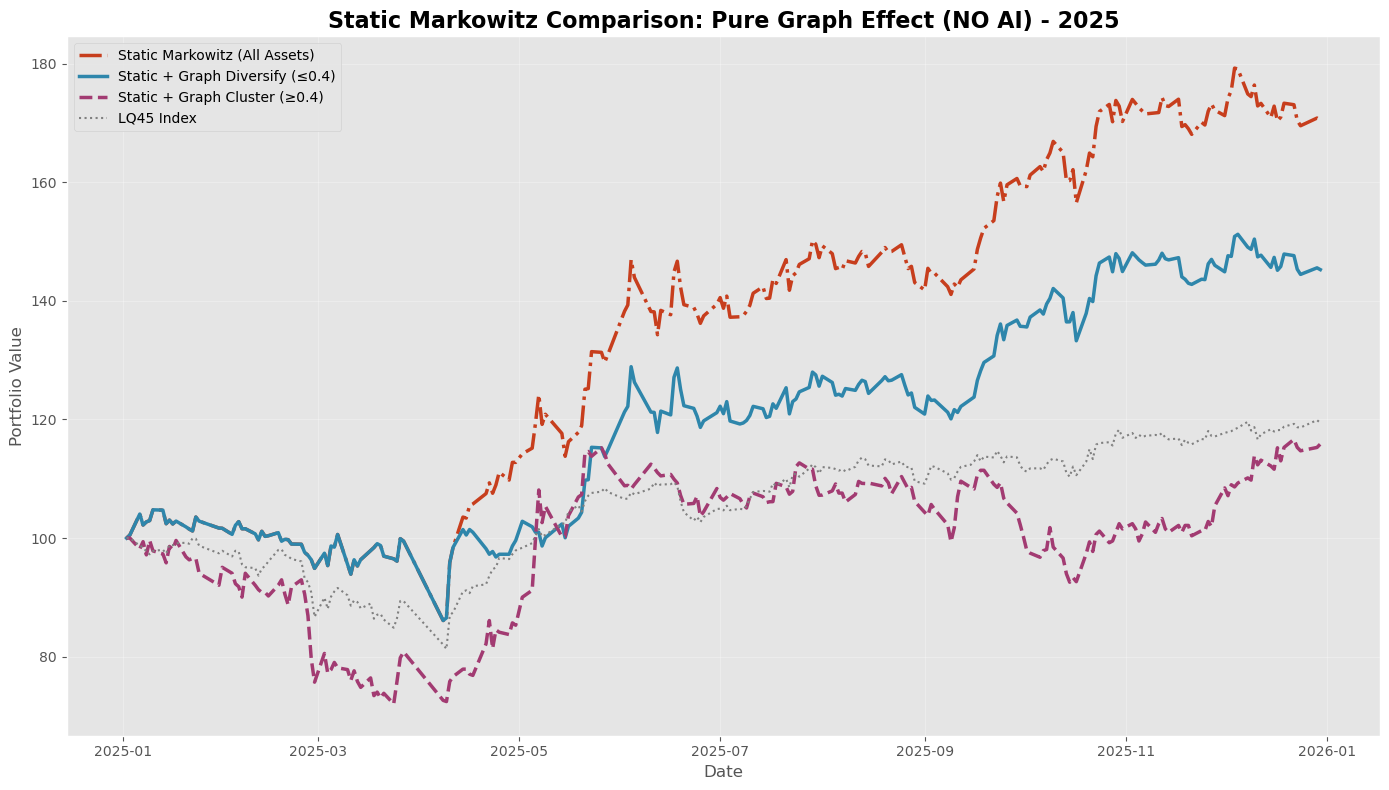


Visualization complete!


In [7]:
# Visualization

plt.figure(figsize=(14, 8))

plt.plot(static_all.index, static_all['Portfolio_Value'], 
         label='Static Markowitz (All Assets)', linewidth=2.5, color='#C73E1D', linestyle='-.')
plt.plot(static_diversify.index, static_diversify['Portfolio_Value'], 
         label='Static + Graph Diversify (≤0.4)', linewidth=2.5, color='#2E86AB')
plt.plot(static_cluster.index, static_cluster['Portfolio_Value'], 
         label='Static + Graph Cluster (≥0.4)', linewidth=2.5, color='#A23B72', linestyle='--')
plt.plot(lq45_idx.index, lq45_idx.values, 
         label='LQ45 Index', linewidth=1.5, color='gray', linestyle=':')

plt.title('Static Markowitz Comparison: Pure Graph Effect (NO AI) - 2025', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nVisualization complete!")

In [8]:
# Calculate Risk Metrics

def calculate_metrics(portfolio_values):
    returns = portfolio_values.pct_change().dropna()
    
    total_return = (portfolio_values.iloc[-1] / portfolio_values.iloc[0] - 1) * 100
    volatility = returns.std() * np.sqrt(252) * 100
    sharpe = (returns.mean() / returns.std()) * np.sqrt(252) if returns.std() > 0 else 0
    max_dd = ((portfolio_values / portfolio_values.cummax()) - 1).min() * 100
    
    return {
        'Total Return (%)': total_return,
        'Volatility (%)': volatility,
        'Sharpe Ratio': sharpe,
        'Max Drawdown (%)': max_dd
    }

metrics_static = calculate_metrics(static_all['Portfolio_Value'])
metrics_diversify = calculate_metrics(static_diversify['Portfolio_Value'])
metrics_cluster = calculate_metrics(static_cluster['Portfolio_Value'])
metrics_index = calculate_metrics(lq45_idx)

results_df = pd.DataFrame({
    'Static (All Assets)': metrics_static,
    'Static + Diversify': metrics_diversify,
    'Static + Cluster': metrics_cluster,
    'LQ45 Index': metrics_index
}).T

print("\n=== RISK METRICS ===")
print(results_df.round(2))

# Export to Excel
output_file = 'v60_static_markowitz_graph_comparison_results.xlsx'
results_df.to_excel(output_file)
print(f"\nResults exported to: {output_file}")


=== RISK METRICS ===
                     Total Return (%)  Volatility (%)  Sharpe Ratio  \
Static (All Assets)             70.50           32.66          1.92   
Static + Diversify              45.27           31.49          1.43   
Static + Cluster                15.85           38.63          0.60   
LQ45 Index                      19.44           20.38          1.04   

                     Max Drawdown (%)  
Static (All Assets)            -17.82  
Static + Diversify             -17.82  
Static + Cluster               -27.97  
LQ45 Index                     -18.70  

Results exported to: v60_static_markowitz_graph_comparison_results.xlsx


## Kesimpulan

### Interpretasi Hasil:

1. **Static Markowitz (All Assets)**:
   - Selection: Semua aset (baseline)
   - Karakteristik: Maximum diversification, no filtering
   - Expected: Moderate return, moderate risk

2. **Static + Graph Diversify**:
   - Selection: Graph MIS (korelasi ≤ 0.4)
   - Karakteristik: Reduced correlation, fewer assets
   - Expected: Lower volatility, higher Sharpe ratio

3. **Static + Graph Cluster**:
   - Selection: Graph MIS (korelasi ≥ 0.4)
   - Karakteristik: Higher correlation, sector concentration
   - Expected: Higher return (bullish), higher volatility

### Pure Graph Effect (NO AI):

Semua strategi **TANPA AI timing**, jadi perbedaan performance murni dari:
- **Graph filtering** (diversify vs cluster)
- **Asset concentration** (fewer assets vs all assets)
- **Correlation structure** (low vs high correlation)

### Key Insights:

**Jika Diversify > Static:**
- Graph diversification add value
- Lower correlation → better risk-adjusted return
- Fewer assets dapat outperform all assets

**Jika Cluster > Static:**
- Sector momentum powerful (bullish market)
- High correlation = strong trend capture
- Concentration risk worth it

**Jika Static > Both:**
- Graph filtering tidak add value tanpa AI
- Maximum diversification superior
- Asset selection tidak penting untuk static strategies

### Rekomendasi:
- **Best Sharpe Ratio** → Optimal risk-adjusted strategy
- **Lowest Volatility** → Most stable approach
- **Best Return** → Best for bullish market
- Compare dengan V59 (with AI) untuk mengukur **AI value**